# Teach a model where code lives

**Add a native event → receive a three-field tensor → learn across executable locations.**

This tutorial extends cpu2tensor with an opt-in `ExecutableLayout` event. We follow the actual C++ and Python implementation, then train a small embedding model on real QEMU traces. A recorded dataset is included so you can run every learning cell without a VM. A later section shows how to capture your own data.

The task is deliberately small: a benign program reads digits `0`–`3`, takes one of four equal-length paths, and echoes the digit. The model sees a captured block address, not the input byte. Can it recognize the same path after the executable moves?

This is a relocation sanity check, not a claim about general program understanding. There are **four distinct semantic paths**, even though we collect many executions. The normalization is supplied by us; the model learns an embedding of the resulting code positions.

## Before you run

From a cpu2tensor checkout, install the package and notebook tools into your own environment:

```sh
python -m pip install -e '.[notebook]'
jupyter lab docs/tutorials/normalization.ipynb
```

Choose that environment as the notebook kernel. CPU is the default. The same training code also supports Apple MPS; CUDA needs its own hardware validation. This notebook does not build, install, download or bundle QEMU.

The native event and helper modules are already implemented in this checkout. Read the small changes below in order, then edit them to experiment. You do not need to apply patches from notebook cells.

In [1]:
from pathlib import Path
import hashlib
import inspect
import json
import os
import struct

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display

from cpu2tensor import ExecutableLayout, Pool, _native
from cpu2tensor.examples.collect_layout import dataset_from_runs
from cpu2tensor.examples.learn_layout import PathModel, address_features, run

# Find files, not Python imports. Install cpu2tensor normally; no sys.path edits.
ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "example/normalization/data/captures.json").exists())
DATA = ROOT / "example/normalization/data/captures.json"
OUTPUT = Path.home() / ".cache/cpu2tensor/normalization-notebook"
DEVICE = os.environ.get("CPU2TENSOR_NOTEBOOK_DEVICE", "cpu")
OUTPUT.mkdir(parents=True, exist_ok=True)
capture = json.loads(DATA.read_text())
print("torch:", torch.__version__, "device:", DEVICE)
print("Recorded data SHA256:", hashlib.sha256(DATA.read_bytes()).hexdigest())

Matplotlib is building the font cache; this may take a moment.


torch: 2.13.0 device: cpu
Recorded data SHA256: e1a51d02bc1e85c16f12129e79328a633764a72a46d2a35ea6ab86c9e4747194


## 1. Define what the fields mean

Before adding a tensor, write its meaning. Our record describes the **initial user process for one worker**, not CPU zero and not a clock shared by different workers.

| Tensor index | Field | Meaning |
| --- | --- | --- |
| 0 | `code_start` | Start of QEMU's nominal executable segment span for the main binary |
| 1 | `code_end` | End of that span, exclusive |
| 2 | `initial_entry` | Initial execution entry reported by QEMU |

`code_start` is our normalization anchor. It is **not necessarily the ELF load bias**: the executable segment can include headers, and a span is not a full mapping table. `initial_entry` may belong to the interpreter of a dynamic executable, outside the main span. Our static tutorial target has no interpreter, so its entry is inside the span.

Scope is intentionally narrow: one initial layout, before execution observations, with no library-load, unload, remap, `exec`, kernel KASLR, PID or binary-identity claims. The collector records the executable SHA-256 separately. Do not merge positions from different binaries just because their offsets match.

These are public QEMU APIs: [start/end/entry documentation](https://www.qemu.org/docs/master/devel/tcg-plugins.html#c.qemu_plugin_start_code). The [QEMU 11.0.3 implementation](https://gitlab.com/qemu-project/qemu/-/blob/v11.0.3/common-user/plugin-api.c.inc) and [Linux-user loader](https://gitlab.com/qemu-project/qemu/-/blob/v11.0.3/linux-user/elfload.c) were checked as well; the interpreter-entry detail is important. We read the fields at first block translation, after loading, rather than during plugin installation.

## 2. Add a small native record

Open `native/include/cpu2tensor/trace.hpp`. The existing protocol is bounded and typed; this example does not add a registry or a generic message framework.

```cpp
inline constexpr uint64_t feature_executable_layout = 1 << 17;
inline constexpr size_t layout_bytes = 24;
// Add to Kind:
// executable_layout = 13
```

The 32-byte header carries `kind=13`, `count=1`, `detail=24`. Source and sequence are both zero **sentinels**, because this is worker metadata. They must not enter per-vCPU progress accounting. The body is three unsigned 64-bit values in little-endian order: start, end, entry. Older decoders reject the unknown feature instead of ignoring information needed to interpret later addresses.

Enable it explicitly with `--layout on` on the worker. The worker passes `layout=on` to the plugin and rejects system-mode requests, where these APIs do not provide the required layout.

## 3. Acquire once, on the correct callback

Open `native/qemu/plugin.cpp`. `emit_layout()` writes one complete 56-byte frame:

```cpp
uint8_t bytes[header_bytes + layout_bytes];
encode_header(bytes, {Kind::executable_layout, 0, 1, 0, layout_bytes});
store_u64(bytes + header_bytes, qemu_plugin_start_code());
store_u64(bytes + header_bytes + 8, qemu_plugin_end_code());
store_u64(bytes + header_bytes + 16, qemu_plugin_entry_code());
```

The implementation checks for a nonempty span and checks publication failure. In the translation callback, it uses `pthread_once`:

```cpp
if (capture_layout && pthread_once(&layout_once, emit_layout) != 0)
    fail(Failure::capture, "cpu2tensor: cannot publish executable layout\n");
```

Each translation waits for the initial publication to complete before its execution callbacks can run. There is no layout getter in a block-execution or memory callback. Register schemas may already have arrived from vCPU initialization; executable observations may not precede the layout.

This is not free: with the option enabled, translation still checks the once state. The important design choice is to keep launch information out of a path executed millions of times. Do not reread these three fields on every memory transaction.

## 4. Validate before making a tensor

Open `native/core/trace.cpp`. The decoder checks the feature, exact row size, zero sentinels, nonempty span, and publication order. It rejects duplicate, missing, unadvertised or system-mode layout records.

The layout branch returns **before** changing `_next[source]` or marking a CPU as observed. Source events therefore keep their original sequence numbers.

Open `native/python/module.cpp`. The decoder allocates one 24-byte `bytearray` and converts each wire integer to host-native order. Python can then use `torch.frombuffer`; the tensor keeps that buffer alive. There is one explicit small decoder allocation/copy here. CPU tensor construction adds no second data copy; accelerator transfer is a separate operation.

The following cell reconstructs a tiny wire fixture from one recorded layout. This is a codec demonstration, not a new live QEMU capture.

In [2]:
def header(kind, *, count=0, detail=0):
    return struct.pack("<IHHIIQQ", 0x31543243, 2, kind, 0, count, 0, detail)

recorded_layout = capture["runs"][0]["layout"]
stream = _native.new_stream()
_native.decode(stream, header(1, detail=1 | (1 << 17)))  # AArch64 + layout feature
wire = header(13, count=1, detail=24) + struct.pack("<3Q", *recorded_layout)
kind, source, count, sequence, detail, owned_bytes = _native.decode(stream, wire)
layout = ExecutableLayout(torch.frombuffer(owned_bytes, dtype=torch.int64))
del owned_bytes  # The tensor retains its native-owned buffer.
assert layout.values.tolist() == recorded_layout
print("Wire bytes:", len(wire), "tensor:", [hex(value) for value in layout.values.tolist()])

Wire bytes: 56 tensor: ['0x5550000', '0x5550228', '0x5550194']


## 5. Expose a simple Python object

Open `python/cpu2tensor/batch.py`. `ExecutableLayout` holds a single tensor; its named properties are views into that tensor. This keeps the three fields easy to inspect without allocating a tensor for each value.

In [3]:
display(Markdown("```python\n" + inspect.getsource(ExecutableLayout) + "\n```"))

```python
@dataclass(frozen=True)
class ExecutableLayout:
    """Initial user-process layout, owned by the worker rather than a vCPU.

    ``values`` holds code_start, code_end (exclusive), initial_entry in that
    order. The code span is QEMU's nominal executable segment span, not an ELF
    load bias or a complete mapping table. A dynamic program's initial entry
    can belong to its interpreter. Later loads/remaps are not represented.
    """

    values: Tensor

    @property
    def code_start(self) -> Tensor:
        return self.values[0]

    @property
    def code_end(self) -> Tensor:
        return self.values[1]

    @property
    def initial_entry(self) -> Tensor:
        return self.values[2]

```

In `python/cpu2tensor/pool.py`, route the new kind through the ordinary batch iterator:

```python
layout = ExecutableLayout(self._tensor(payload, torch.int64))
return Batch(None, None, empty_addresses, layout=layout)
```

`batch.source is None` and `batch.first_sequence is None` identify worker metadata. Blocks keep their real CPU source and sequence. No opaque trajectory identifier or asynchronous client API is introduced. `StdioEnv` routes the same event as an observation, although this tutorial needs no actions.

A live client can keep the layout for the lifetime of one Pool and normalize blocks as they arrive:

```python
with Pool([endpoint]) as pool:
    layout = None
    for batch in pool.read():
        if batch.layout is not None:
            layout = batch.layout
        elif batch.addresses.numel():
            # For this static target only: all blocks lie in the reported span.
            offsets = batch.addresses - layout.code_start
            # Consume offsets in your model or batch builder.
```

Do not apply a main-executable anchor to arbitrary shared-library PCs. In a more general client, select the applicable mapping and preserve unknown attribution.

## 6. Inspect the real experiment

The target is `native/examples/layout_paths.S`. It uses direct Linux read/write/exit syscalls. Each digit chooses one of four equal-length code paths and reaches the exported `sample_end` marker. The feature reducer keeps the **block immediately before that marker**. It receives no labels or input bytes. Labels are attached from the prescribed input only after capture has completed.

Both model comparisons use this same metadata-assisted sample segmentation. Only the normalized model uses the anchor in its address features. The symbol/input oracle checks the collected address for correctness; it does not replace that address with a class label.

All 11 runs use the **same static PIE binary**. QEMU's explicit `-R` reserved-address-space setting produces different actual guest locations. This is controlled relocation, not random ASLR. Changing `-B` would change the host mapping, not provide this guest-address experiment.

Seven locations were assigned to training and four to testing **before capture**. Every location has 32 observations of each class. All guest output bytes matched the input and all processes exited successfully.

In [4]:
dataset = dataset_from_runs(capture)
rows = ["| Split | QEMU -R | Measured code start | Samples | Blocks |", "|---|---|---:|---:|---:|"]
for item in capture["runs"]:
    rows.append(f"| {'train' if item['train'] else 'held out'} | {item['reserved_va']} | "
                f"`{item['layout'][0]:#x}` | {len(item['pc'])} | {item['full_block_count']} |")
display(Markdown("\n".join(rows)))
print(capture["provenance"]["capture"])
print("Training / held-out samples:", int(dataset["train"].sum()), int((~dataset["train"]).sum()))

| Split | QEMU -R | Measured code start | Samples | Blocks |
|---|---|---:|---:|---:|
| train | 128M | `0x5550000` | 128 | 1156 |
| train | 192M | `0x8000000` | 128 | 1156 |
| train | 256M | `0xaaa0000` | 128 | 1156 |
| train | 384M | `0x10000000` | 128 | 1156 |
| train | 512M | `0x15550000` | 128 | 1156 |
| train | 768M | `0x20000000` | 128 | 1156 |
| train | 1G | `0x2aaa0000` | 128 | 1156 |
| held out | 1536M | `0x40000000` | 128 | 1156 |
| held out | 2G | `0x55550000` | 128 | 1156 |
| held out | 3G | `0x80000000` | 128 | 1156 |
| held out | 4G | `0xaaaa0000` | 128 | 1156 |

real cpu2tensor worker -> TCP -> native validation -> Pool tensors
Training / held-out samples: 896 512


## 7. Subtract before converting to floating point

Raw addresses retain exact bits in `int64`. Compute the difference there. Large addresses converted to `float32` can collapse several neighboring instructions to the same value, before a model even sees them.

For this static target, the embedding input is simply `PC - code_start`. `code_end` checks that the PC belongs to the expected span. `initial_entry` helps validate the static launch. The three fields have different roles; we do not pretend the model learns from three independent signals.

In [5]:
last = capture["runs"][-1]
raw = torch.tensor(last["pc"], dtype=torch.int64).flatten().unique()
anchor = torch.tensor(last["layout"][0], dtype=torch.int64)
print("Distinct raw integer PCs:", raw.numel())
print("Distinct after float32 conversion:", raw.float().unique().numel())
print("Exact relative positions:", (raw - anchor).tolist())

relative = address_features(dataset["pc"], dataset["layout"], normalized=True)
assert relative.unique().numel() == 4
assert not set(dataset["layout"][dataset["train"], 0].tolist()) & set(dataset["layout"][~dataset["train"], 0].tolist())
print("Raw positions / relative positions:", dataset["pc"].unique().numel(), relative.unique().numel())

Distinct raw integer PCs: 4
Distinct after float32 conversion: 1
Exact relative positions: [468, 476, 484, 492]
Raw positions / relative positions: 44 4


## 8. Learn a position embedding

The model is an embedding table followed by a four-class linear classifier. For this one-block feature, averaging is trivial; the same model accepts padded sequences.

The vocabulary is fit on **training rows only**. An unseen address receives token zero. Raw and normalized comparisons use the same parameter capacity, initialization seed, optimizer and 80-epoch budget. The raw model can learn training addresses, but every held-out absolute address is unknown. Relative positions reuse training tokens.

This makes the baseline's limitation explicit: it is an **exact-address vocabulary**. A different model could learn arithmetic or another address representation. Our result will show that supplying the coordinate transform lets this small embedding model share knowledge across relocation.

In [6]:
display(Markdown("```python\n" + inspect.getsource(PathModel) + "\n```"))

```python
class PathModel(torch.nn.Module):
    """Average learned block embeddings, then predict one of four paths."""

    def __init__(self, vocabulary_size: int, width: int = 16) -> None:
        super().__init__()
        self.embedding = torch.nn.Embedding(vocabulary_size, width)
        self.classifier = torch.nn.Linear(width, 4)

    def forward(self, tokens: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        weights = mask.unsqueeze(-1)
        pooled = (self.embedding(tokens) * weights).sum(1) / weights.sum(1)
        return self.classifier(pooled)

```

The readable training loop is in `python/cpu2tensor/examples/learn_layout.py`. It uses ordinary PyTorch:

```python
optimizer.zero_grad(set_to_none=True)
loss = torch.nn.functional.cross_entropy(model(tokens, mask), labels)
loss.backward()
optimizer.step()
```

We also run a metadata-only model and a shuffled-training-label control. At each held-out location, metadata is identical for all four balanced labels, so metadata alone cannot identify the path. Finally, the trained normalized model is evaluated with another held-out worker's layout.

Seeds `(7, 17, 29)` and all 80 epochs are fixed. No seed selection, early stopping or best-held-out-checkpoint selection is used. Every final checkpoint is saved, reloaded and checked for identical predictions.

In [7]:
report = run(dataset, OUTPUT / DEVICE, device=DEVICE, epochs=80, seeds=(7, 17, 29))
summary = ["| Mode | Seed | First → final training loss | Held-out accuracy |", "|---|---:|---:|---:|"]
for item in report["runs"]:
    first, final = item["history"][0], item["history"][-1]
    summary.append(f"| {item['mode']} | {item['seed']} | {first['train_loss']:.4f} → "
                   f"{final['train_loss']:.4f} | {final['heldout_accuracy']:.0%} |")
display(Markdown("\n".join(summary)))

| Mode | Seed | First → final training loss | Held-out accuracy |
|---|---:|---:|---:|
| raw | 7 | 1.5748 → 0.0001 | 25% |
| normalized | 7 | 1.5909 → 0.0000 | 100% |
| metadata_only | 7 | 1.4998 → 1.3863 | 25% |
| shuffled_labels | 7 | 1.5505 → 1.3840 | 50% |
| raw | 17 | 1.6950 → 0.0001 | 25% |
| normalized | 17 | 1.5174 → 0.0001 | 100% |
| metadata_only | 17 | 1.4940 → 1.3863 | 25% |
| shuffled_labels | 17 | 1.4169 → 1.3816 | 0% |
| raw | 29 | 1.5866 → 0.0001 | 25% |
| normalized | 29 | 1.3669 → 0.0000 | 100% |
| metadata_only | 29 | 1.4706 → 1.3863 | 25% |
| shuffled_labels | 29 | 1.4964 → 1.3821 | 25% |

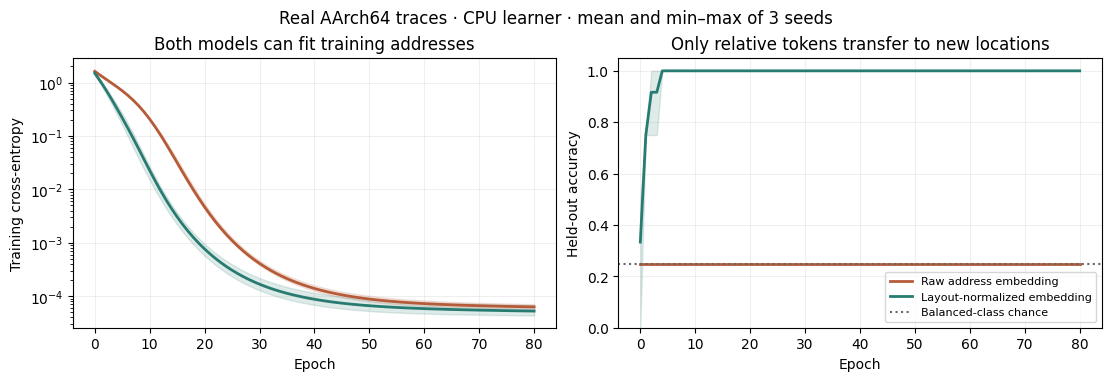

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), constrained_layout=True)
colors = {"raw": "#b65b38", "normalized": "#277b70"}
for mode, label in [("raw", "Raw address embedding"), ("normalized", "Layout-normalized embedding")]:
    histories = [item["history"] for item in report["runs"] if item["mode"] == mode]
    epochs = [point["epoch"] for point in histories[0]]
    for axis, field in zip(axes, ["train_loss", "heldout_accuracy"]):
        values = torch.tensor([[point[field] for point in history] for history in histories])
        axis.plot(epochs, values.mean(0), color=colors[mode], label=label, linewidth=2)
        axis.fill_between(epochs, values.min(0).values, values.max(0).values,
                          color=colors[mode], alpha=0.15)
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.2)
axes[0].set(title="Both models can fit training addresses", ylabel="Training cross-entropy", yscale="log")
axes[1].set(title="Only relative tokens transfer to new locations", ylabel="Held-out accuracy", ylim=(0, 1.05))
axes[1].axhline(0.25, color="#666666", linestyle=":", label="Balanced-class chance")
axes[1].legend(loc="lower right", fontsize=8)
fig.suptitle(f"Real AArch64 traces · {DEVICE.upper()} learner · mean and min–max of 3 seeds")
fig.savefig(OUTPUT / f"learning-{DEVICE}.png", dpi=160)
plt.show()

## 9. Check what the result does—and does not—show

The shaded range is variation across three fixed initialization seeds, **not a confidence interval over programs**. The dataset has four underlying paths. Repeating them at new locations tests coordinate alignment; it does not create thousands of independent semantic tasks.

The next cell checks the direct controls. A shuffled-label model can accidentally assign the right class to one or two of four paths, giving 25% or 50% accuracy while its loss and confidence remain near chance. Report those outcomes instead of choosing a seed with a more convenient accuracy.

In [9]:
for item in report["runs"]:
    final = item["history"][-1]
    if item["mode"] == "normalized":
        print(f"seed {item['seed']}: normalized {final['heldout_accuracy']:.0%}; "
              f"wrong worker layout {item['wrong_metadata_accuracy']:.0%}")
    if item["mode"] == "shuffled_labels":
        print(f"seed {item['seed']}: shuffled labels {final['heldout_accuracy']:.0%}; "
              f"held-out loss {final['heldout_loss']:.3f}; "
              f"mean correct-class probability {final['heldout_correct_probability']:.3f}")
assert all(item["checkpoint_reload"] for item in report["runs"])
print("All final checkpoints reload with unchanged predictions.")

seed 7: normalized 100%; wrong worker layout 25%
seed 7: shuffled labels 50%; held-out loss 1.331; mean correct-class probability 0.264
seed 17: normalized 100%; wrong worker layout 25%
seed 17: shuffled labels 0%; held-out loss 1.439; mean correct-class probability 0.238
seed 29: normalized 100%; wrong worker layout 25%
seed 29: shuffled labels 25%; held-out loss 1.349; mean correct-class probability 0.260
All final checkpoints reload with unchanged predictions.


## 10. Capture your own relocated executions

The default notebook uses recorded data. To replace it, an operator supplies a Linux AArch64 worker, matching QEMU/plugin headers and build dependencies. Build the normal worker as described in [the quickstart](../quickstart.md). On Linux AArch64, its CMake build also creates `layout_paths`. Nothing in the package installs QEMU.

On the worker, keep `QEMU` and `C2T_BUILD` from the quickstart. Set `WORKER_ADDRESS` to an address reachable by your learner (loopback works when both are on the same machine, or with your own SSH tunnel). Generate a balanced input file without a trailing newline:

```sh
export WORKER_ADDRESS=127.0.0.1  # Replace with the worker address for a remote learner.
python -c 'import random; x=list("0123"*32); random.Random(103).shuffle(x); print("".join(x),end="")' > input.txt
nm -n "$C2T_BUILD/layout_paths"    # Read the sample_end symbol; do not blindly reuse a stale offset.
readelf -l "$C2T_BUILD/layout_paths"  # This target has executable LOAD vaddr 0 and no interpreter.

"$C2T_BUILD/cpu2tensor-worker" --qemu "$QEMU" \
  --plugin "$C2T_BUILD/libcpu2tensor_plugin.so" --input input.txt \
  --host "$WORKER_ADDRESS" --registers none --memory off --layout on \
  -- -R 128M "$C2T_BUILD/layout_paths"
```

For this exact build, `sample_end` minus the executable segment's linked start is the marker offset. `nm` alone is not a general ELF load-bias calculation. Recheck the segment address after changing the build.

The worker prints its endpoint. Copy the same input file to the learner and collect the run:

```sh
python -m cpu2tensor.examples.collect_layout tcp://HOST:PORT \
  --input input.txt --sample-end-offset OFFSET_FROM_YOUR_ELF \
  --split train --output run-128M.json
```

Repeat with the same binary and the 11 `-R` settings listed above. Use `--split test` only for the last four settings. Verify the target's echoed stdout, exit status, program hash and measured locations. Distinct `-R` values are not a general promise of distinct load addresses across all QEMU releases; the dataset validator rejects overlapping splits.

Assemble `{"format": 1, "runs": [...]}` from these JSON run files and load it through `dataset_from_runs`. Keep launch commands and binary identities alongside it. Host provisioning, SSH and dependency installation remain operator work.

## 11. Price the signal and extend it

The event adds **24 payload bytes + 32 header bytes = 56 wire bytes per worker launch**. The recorded runs each contain 1,156 block events. There is one three-integer tensor per worker, not one per block. Integer normalization can operate on a whole block batch.

These are size/work-count facts, not measured speedups. The option adds a translation-side once check and one publication. To measure execution cost, use the [capture benchmark](../benchmark-capture.md) on the **same host, QEMU, input and binary**, comparing layout off/on with the same block-only configuration. Separate that cost from tensor preparation and training. Do not compare ARM and x86 wall times as if they were the same environment.

To add a fourth field, follow the same source path:

1. Define its exact meaning, scope, availability and lifetime. For example, an ELF identity helps compare positions across binaries; a filename alone is not enough.
2. Acquire it at a supported cold callback. Do not turn a launch signal into a per-instruction getter.
3. Give a changed mandatory wire layout a new capability/version or record kind. Do not silently change the 24-byte contract under the existing feature bit.
4. Update native validation and conversion, then the Python tensor and Pool routing together.
5. Add an independent oracle, ownership checks and a learning control that breaks the new field deliberately.

If you need library mappings or later remaps, define a mapping-lifetime event rather than stretching this initial-layout record. Keep worker-wide metadata separate from vCPU order, and do not treat it as synchronization across workers.

Relevant tests: `test_executable_layout.py`, `test_layout_collection.py`, `test_layout_learning.py`. They check worker scope, malformed framing, CPU/MPS ownership, marker boundaries, exact integer arithmetic, split isolation, finite training and checkpoint reload. See [the evidence note](../normalization-results.md) for the actual run and remaining limits.